# Confidence Intervals and Test Assumptions

Mathematical equivalance between confidence intervals and hypothesis tests, test assumptions (independence, normality, equal variances).

## 1. Confidence Intervals and Test Assumptions

In the previous notebook , we established the foundations of Hypothesis testing p-values, null and alternative hypothesis and test statistic. Now we explore  two complementary concepts that completed your understanding of statistical inference.

First, we'll discover that confidence intervals and hypothesis tests are mathematically equivalent. They're not two different methods for analyzing data; they're two perspectives on the same underlying calculation. Understanding this equivalence transforms how you interpret both tools.

Second, we'll examine the assumptions that make statistical tests work. Every test rests on mathematical assumptions, and when these assumptions are violated, tests can mislead you. Knowing what assumptions matter, when they matter, and what to do when they fail is essential for responsible data analysis.

## 2. Confidence Intervals: A Deeper Look

You've probably seen confidence intervals before: *"The average treatment effect was 5.2 with a 95% confidence interval of [3.1, 7.3]."* But what does this mean, and how does it connect to hypothesis testing?

### What a Confidence Interval really Means

A 95% confidence interval does NOT mean there's a 95% probability that the true parameter lies within the interval. The true parameter is fixed (though unknown). It's either inside the interval or it isn't. There's no probability involved once you've computed the interval.

>**Confidence Interval Interpreatation :**
>A 95% confidence interval means: if we repeated our sampling procedure many times and computed a confidence interval each time, 95% of those intervals would contain the true parameter value.

This is a subtle but important distinction. The confidence refers to the procedure, not to any particular interval. Over many repetitions, 95% of the intervals produced by this method will capture the true value.

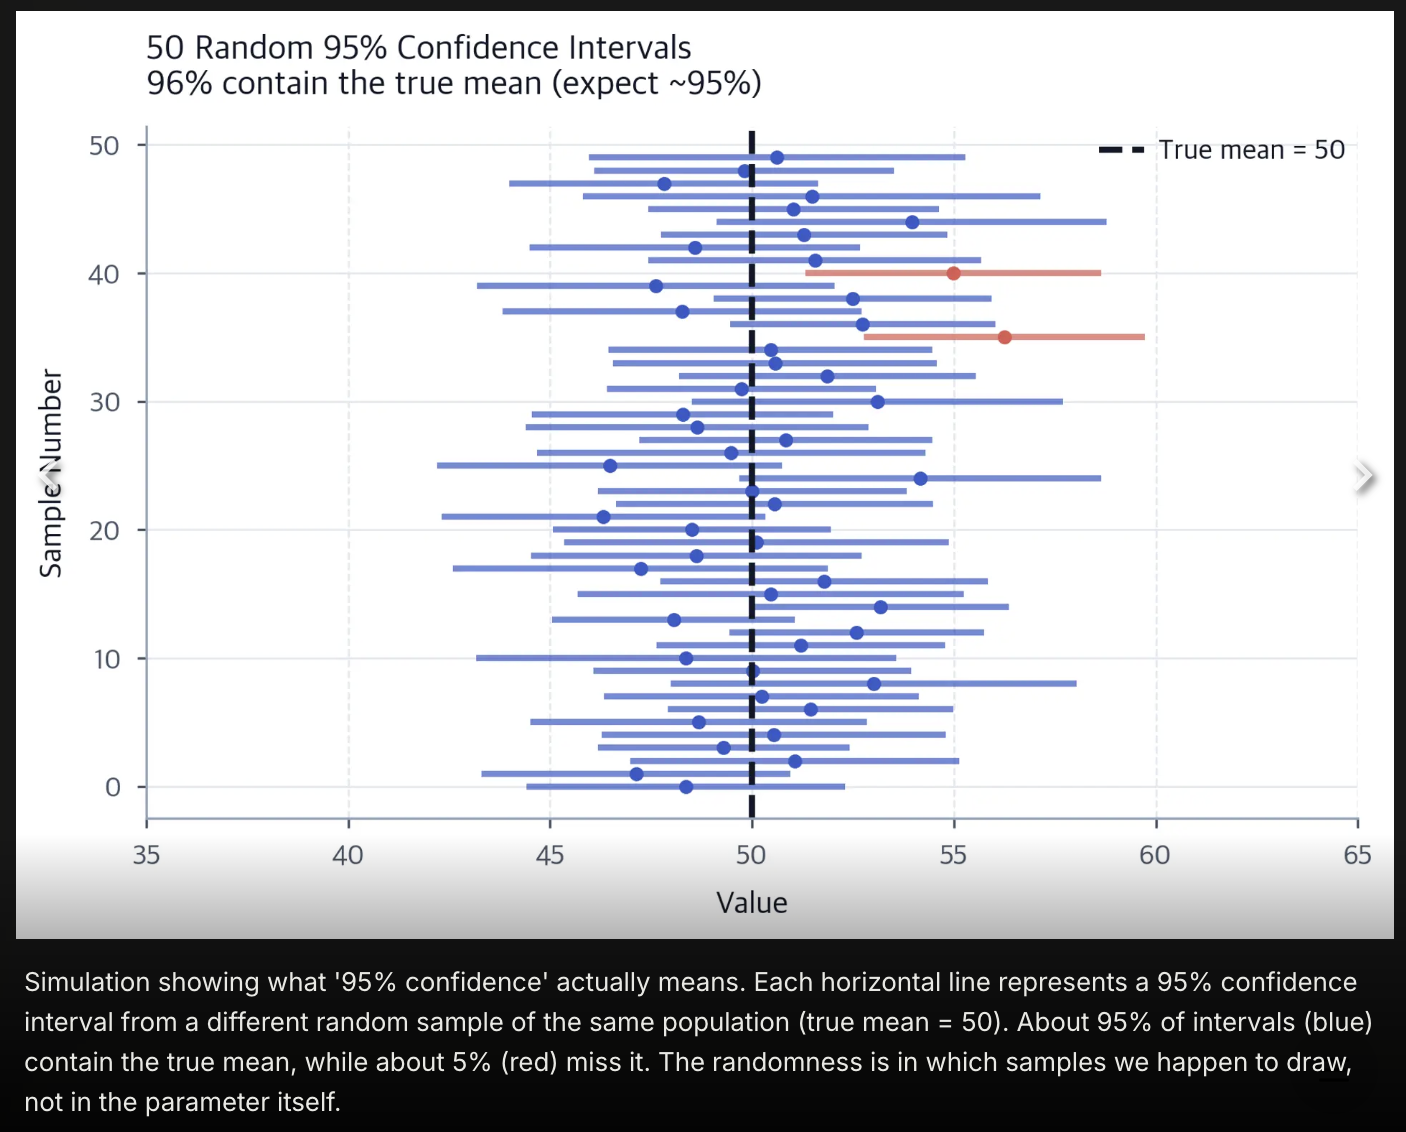


### Constructing a Confidence Interval Step By Step
Let's build a confidence interval from first principles. Suppose you have a sample of n observations and want a 
$(1− α) × 100%$
confidence interval for the population mean.

**Step 1: Calculate the Sample Mean**

$$\hat{x} = \frac{1}{n} \sum_{i=1}^{n}{x_i}$$

**Step 2: Calculate the Standard Error**

The standard error measures how much the sample mean varies from sample to sample. If you know the population standard deviation $σ$:

$$SE = \frac{\sigma}{\sqrt(n)}$$

If you don't know $\sigma$ , estimate it with the sample standard deviation :

$$SE = \frac{\sigma}{\sqrt(n)} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}[{x_i - \hat{x}}]^2}$$

**Step 3 : Find the Critical Value**:

For a 95% confidence interval ($α= 0.05$), you need the value that cuts off 2.5% in each tail of the distribution.

If you know $\sigma$ use the $z$ critical value : $z_{1- \frac{\alpha}{2} = z_{0.975} =. 1.96}$

**Step 4: Construct the interval**



In [2]:
import numpy as np
from scipy import stats

# Sample Data: reaction time in milliseconds
reaction_times = np.array(
    [
        245,
        268,
        252,
        241,
        259,
        263,
        248,
        271,
        255,
        249,
        262,
        247,
        258,
        244,
        266,
        253,
        260,
        242,
        257,
        251,
    ]
)

#Step 1: Sample mean
n = len(reaction_times)
sample_mean = np.mean(reaction_times)

#Step 2: Standard Error
sample_std = np.std(reaction_times, ddof=1)
standard_error = sample_std / np.sqrt(n)


# Step 3: Critical Value of 95% CI
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha / 2, df = n-1)

# Step 4: Construct the interval
margin_of_error = t_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"Sample size: n = {n}")
print(f"Sample mean: x̄ = {sample_mean:.2f} ms")
print(f"Sample std: s = {sample_std:.2f} ms")
print(f"Standard error: SE = {standard_error:.2f} ms")
print(f"t critical value (df={n - 1}): t = {t_critical:.3f}")
print(f"Margin of error: {margin_of_error:.2f} ms")
print(f"\n95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}] ms")



Sample size: n = 20
Sample mean: x̄ = 254.55 ms
Sample std: s = 8.80 ms
Standard error: SE = 1.97 ms
t critical value (df=19): t = 2.093
Margin of error: 4.12 ms

95% Confidence Interval: [250.43, 258.67] ms


## 3. The Remarkable Equivalance

Here is the key insight that connects confidence intervals to hypothesis testing: *a 95% confidence interval contains exactly those parameters values that would not be rejected by a two-sided hypothesis test at 0.05 significance level.*

### Why the Equivalane Holds

Lets Prove it algebraically: Consider testing $H_0=\mu = \mu_0$ versus $H_0=\mu \neq \mu_0$ at siginfiance of $\alpha = 0.05$

We reject $H_0$ when test statistic exceeds the critical value:
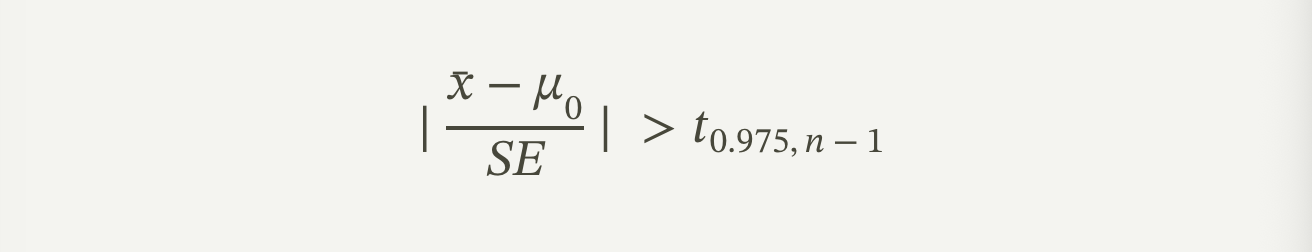
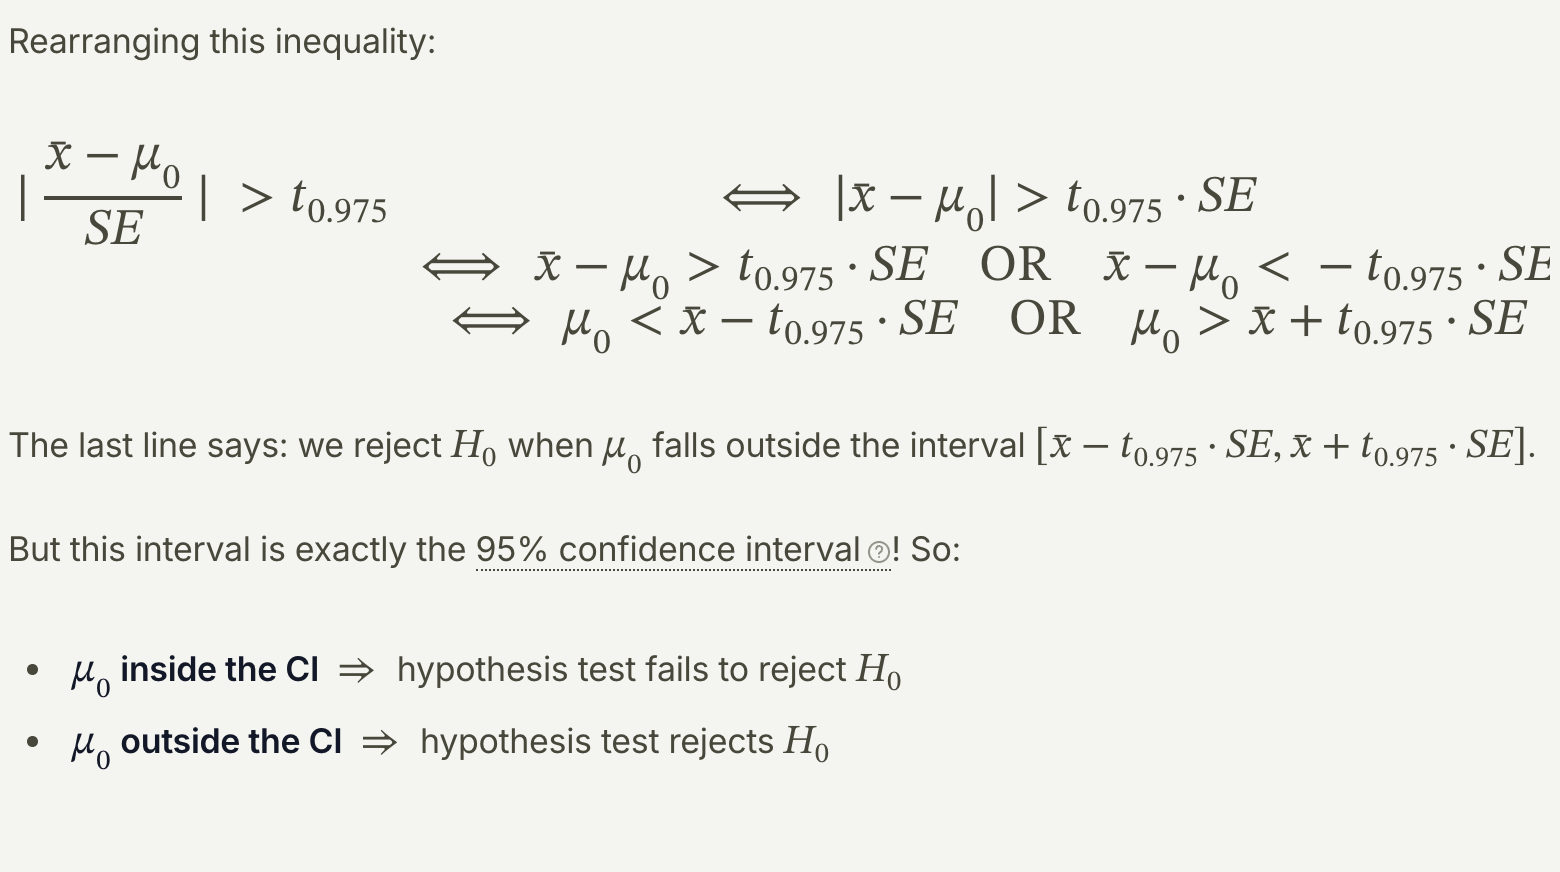

The confidence interval is the set of all parameter values that would not be rejected as null hypotheses.

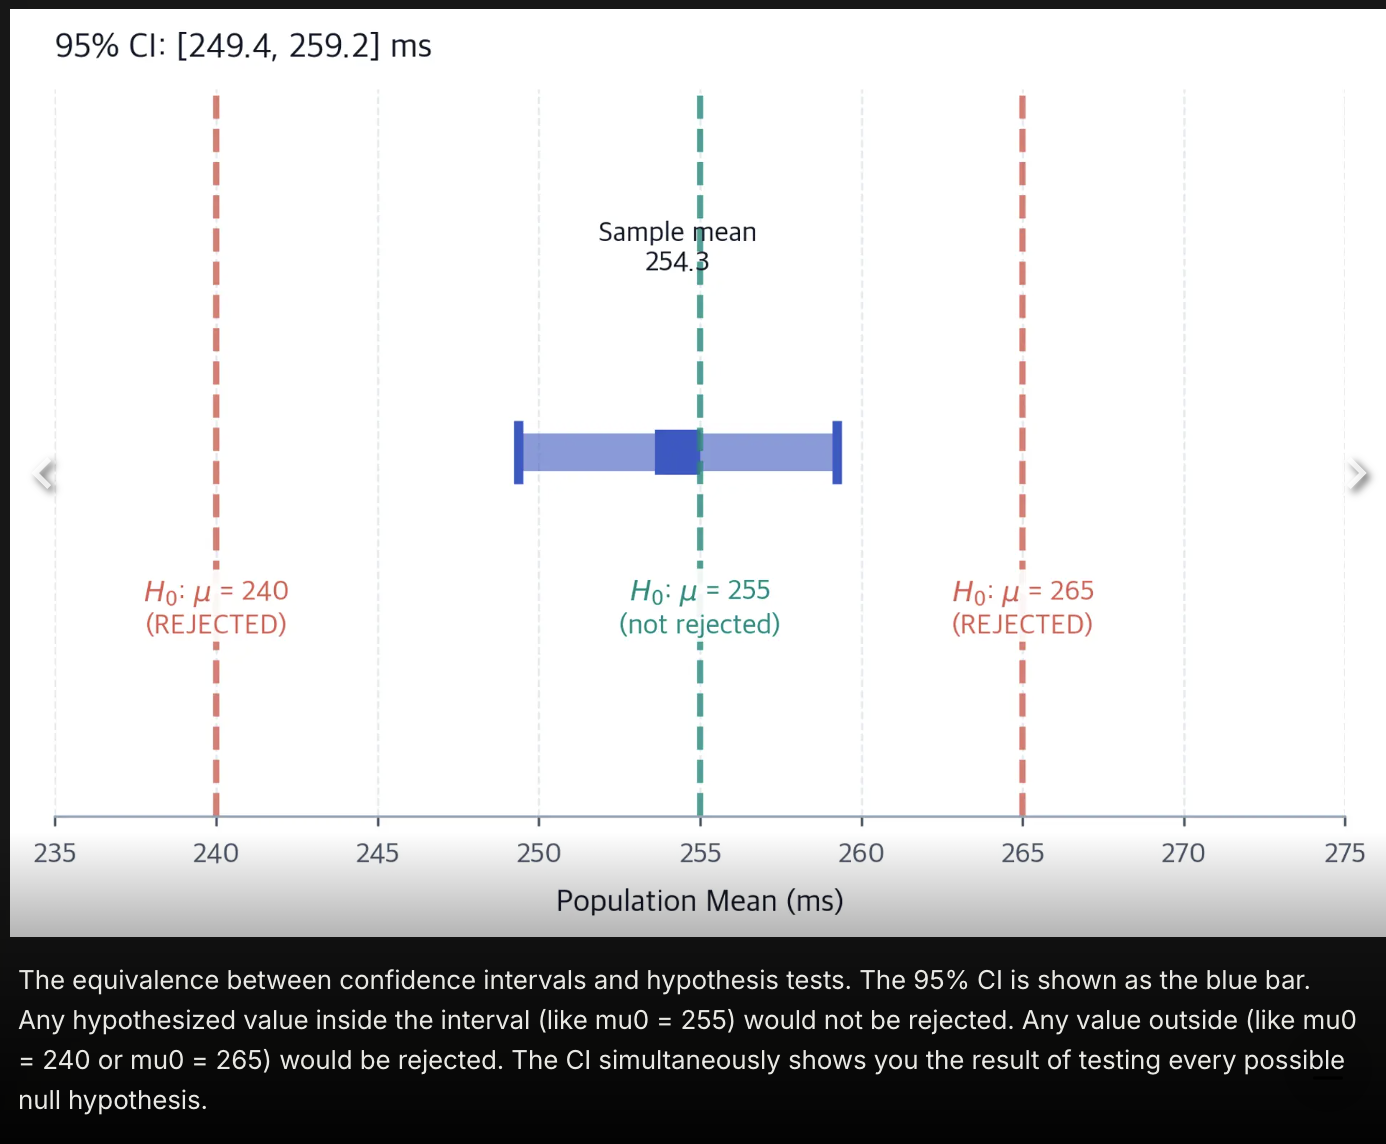

###  Why this matters practically?

This equivalence has important practical implications:

1. **Confidence intervals are more informative than p-values**. A p-value tells you whether one specific null hypothesis is rejected. A confidence interval tells you which values would be rejected and which wouldn't. It's like the difference between asking "Is the speed limit 65 mph?" versus "What range of speed limits are consistent with my speedometer reading?"

2. **You can read significance from a CI**. If a 95% CI for a difference doesn't include zero, the difference is significant at the 0.05 level. If the CI for a ratio doesn't include 1, the ratio is significant. You don't need to compute a separate test.

3. **CIs convey precision**. A CI of [0.1, 0.3] and a CI of [-2, 5] might both exclude zero (both "significant"), but the first shows you know the effect is small and positive, while the second shows you barely know anything at all.

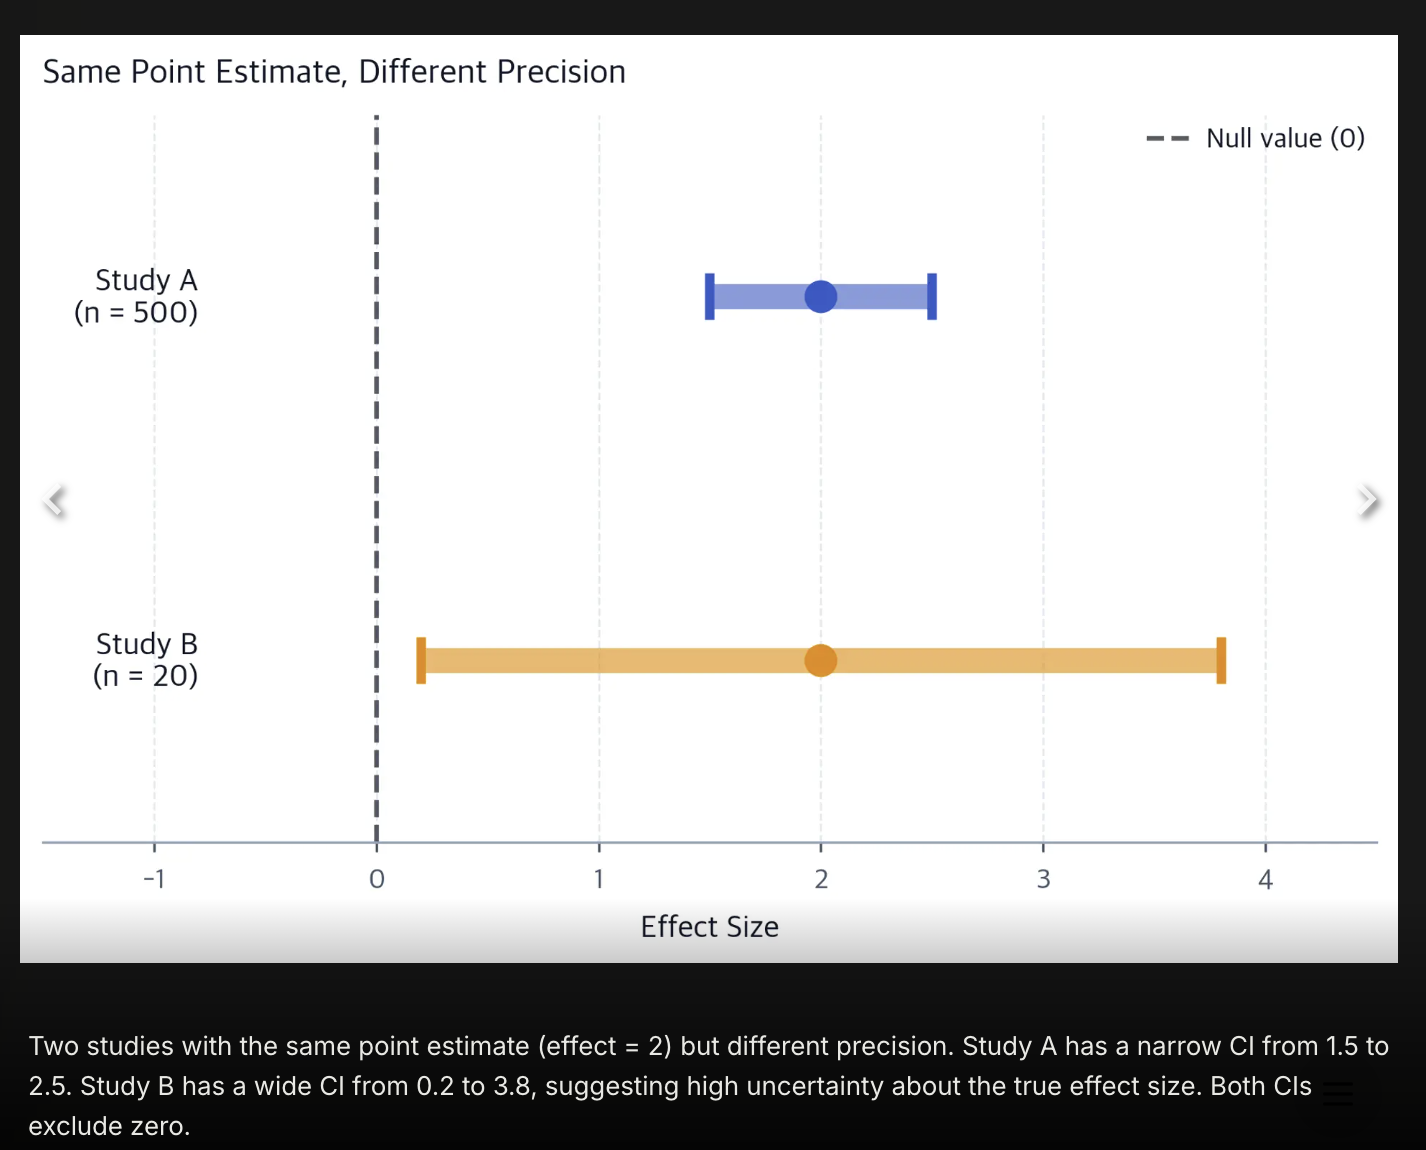

## 4. Test Assumptions: The Foundation of Valid Infernece

Every statistical test is built on assumptions. When these assumptions hold, the test does what it claims: it controls the Type I error rate at the specified level and has known power properties. When assumptions are violated, these guarantees may break down.

Understanding assumptions isn't about rigidly checking boxes. It's about understanding when violations matter, when they don't, and what alternatives exist.

**Assumption 1: Independence**:

Independence is the most important assumption and the one most commonly violated without recognition.

**What independence means**: Each observation provides unique information. The value of one observation doesn't tell you anything about another observation's value.

**Why it matters**: Statistical tests calculate standard errors assuming each observation contributes independent information. When observations are correlated, the effective sample size is smaller than the actual sample size. The test "thinks" it has more information than it does, leading to standard errors that are too small, test statistics that are too large, and p-values that are too small.

**Common violations**:

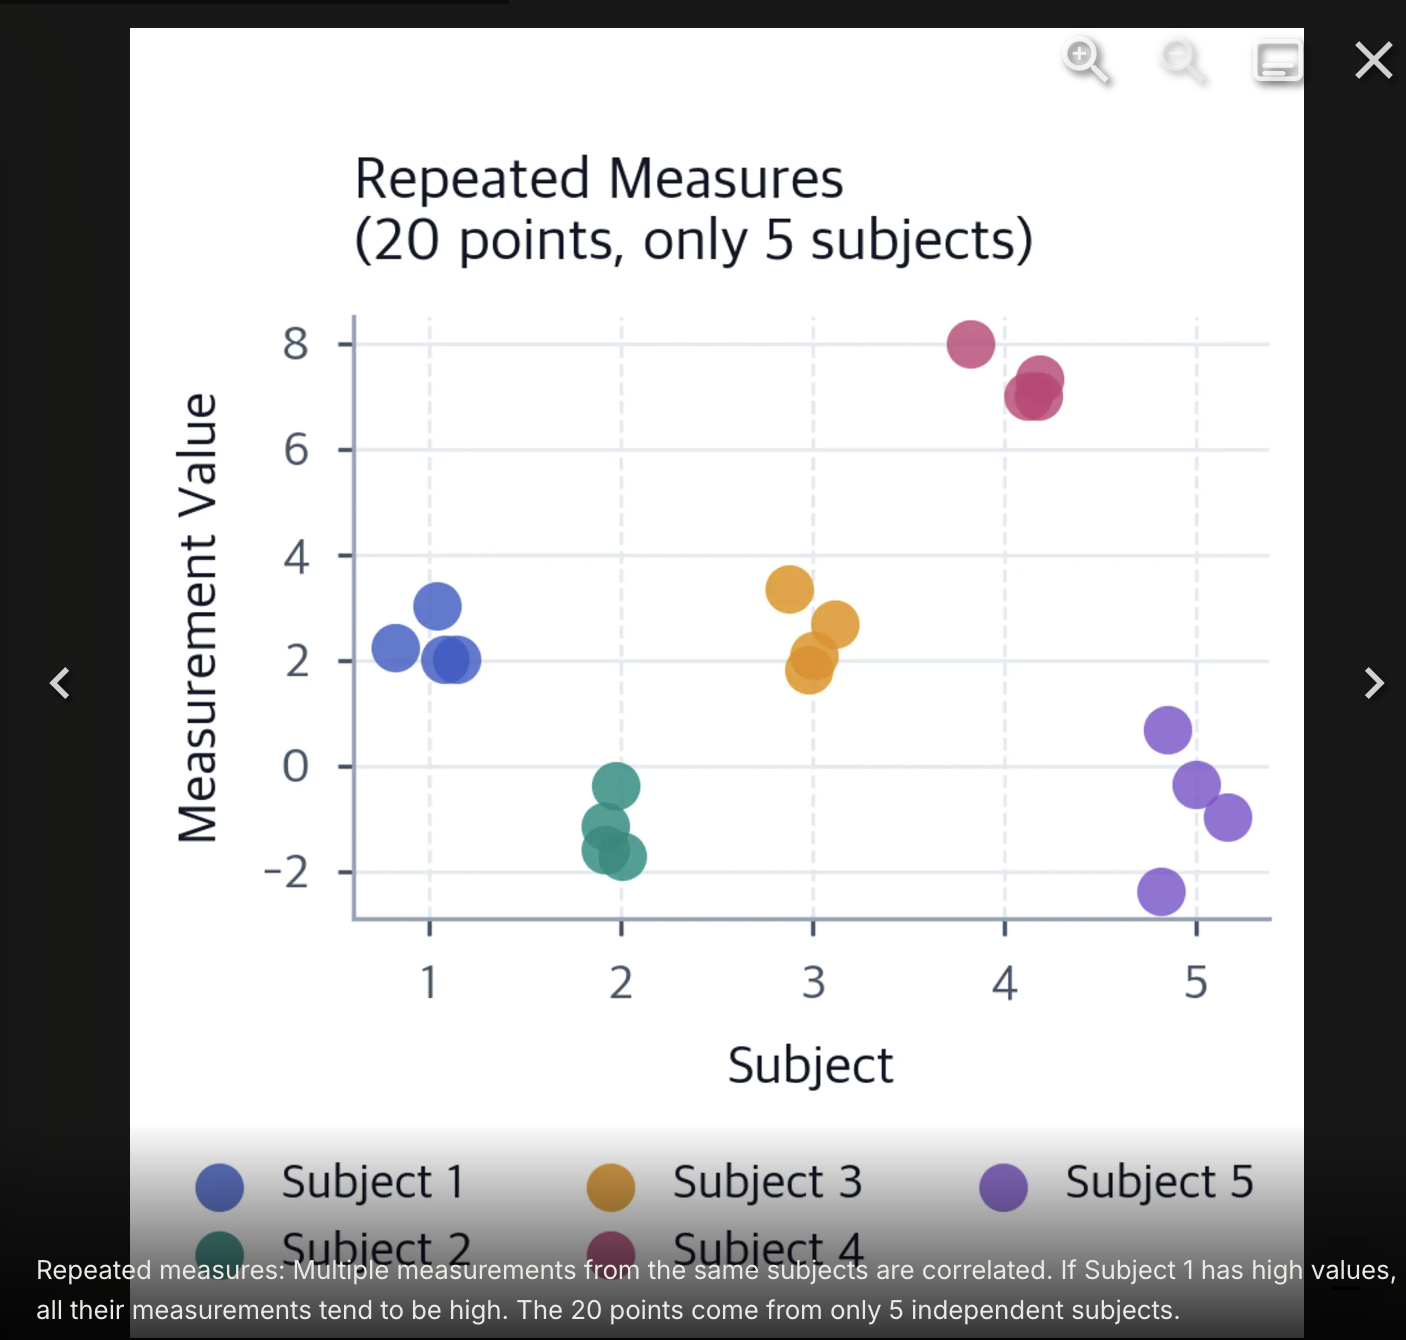
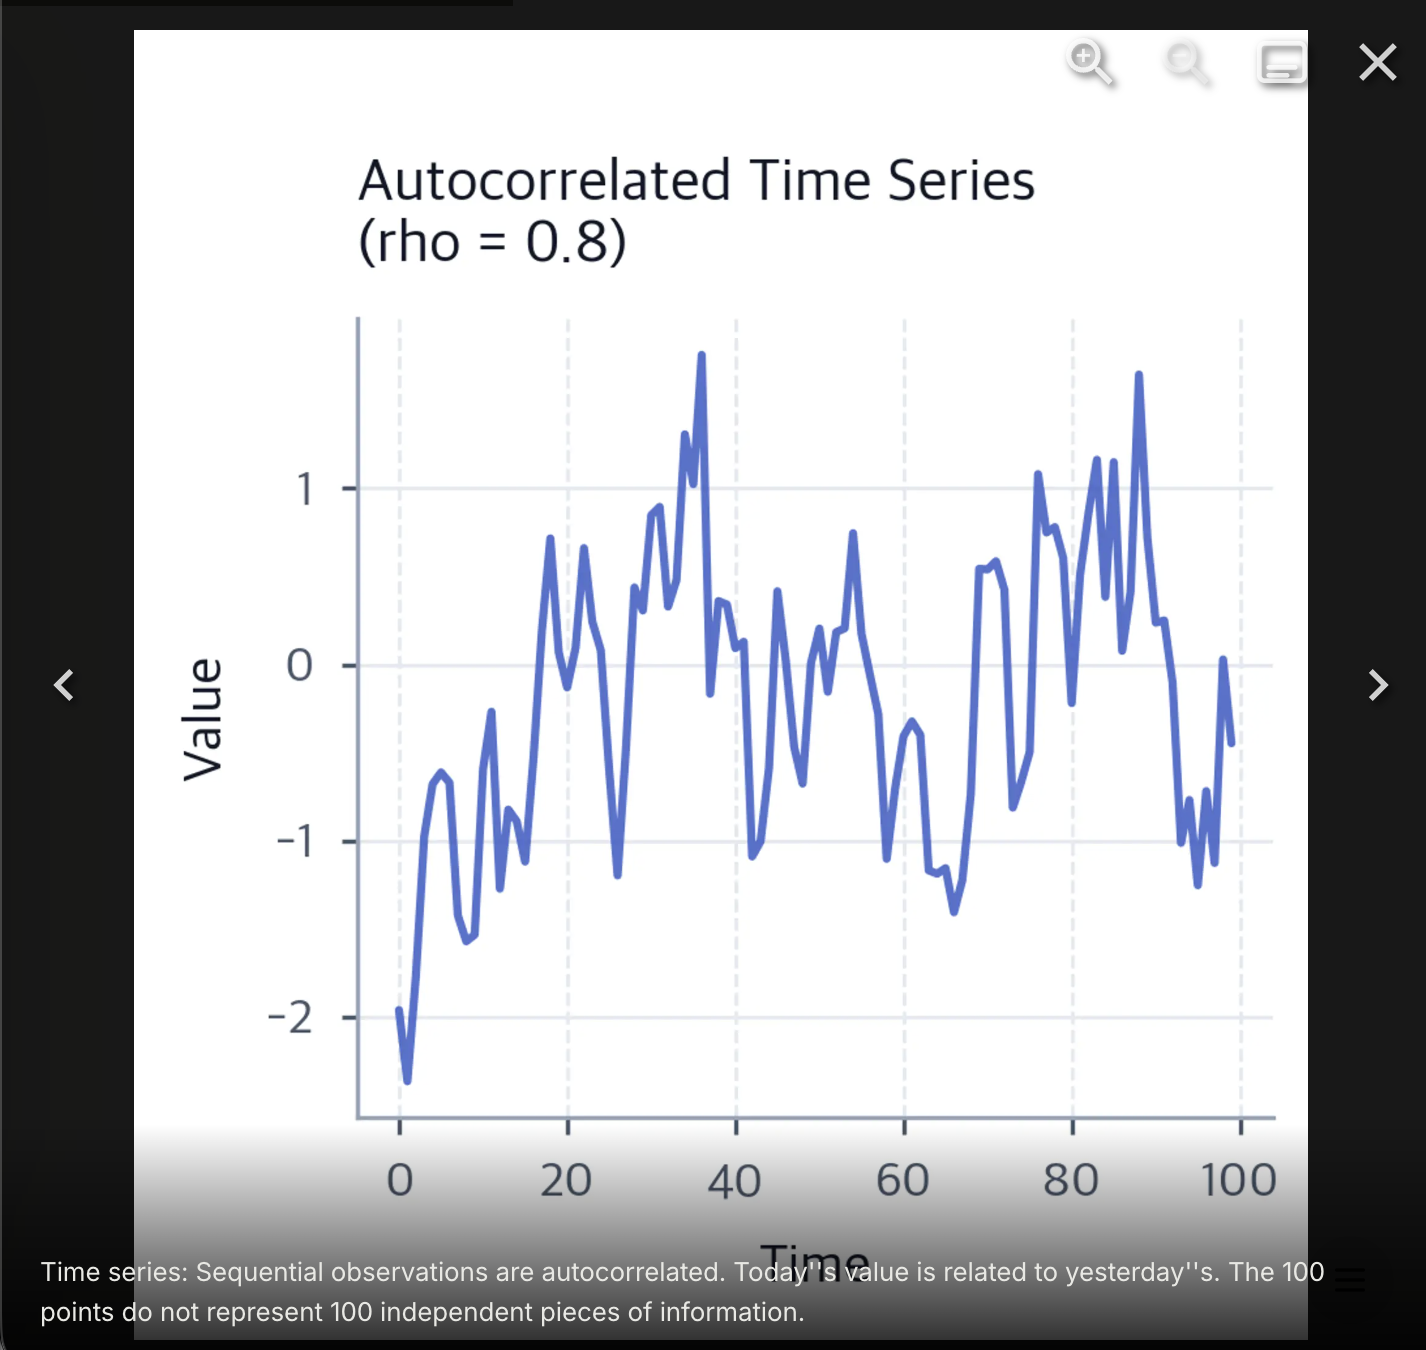

**The consequences**: If you analyze repeated measures as if they were independent, your standard errors will be too small (often dramatically so), your p-values will be too small, and you'll make many more false positive claims than you think. A study that appears to have n=100 might effectively have n=10 if each of 10 subjects contributes 10 correlated measurements.

**Solutions**: Use methods designed for your data structure:

- **Repeated measures**: paired t-tests, repeated measures ANOVA, mixed-effects models
- **Clustered data**: cluster-robust standard errors, mixed-effects models
- **Time series**: ARIMA models, autocorrelation-corrected standard errors



**Assumption 2: Normality**
Many tests assume the data (or the sampling distribution of a statistic) is normally distributed.

**What normality means**: The t-test and z-test assume that the sampling distribution of the mean is normal. For small samples, this requires the population itself to be approximately normal. For large samples, the Central Limit Theorem saves us.

**The Central Limit Theorem**: This remarkable theorem states that the sampling distribution of the mean approaches normality as sample size increases, regardless of the population distribution. This is why t-tests work even when individual observations aren't normal.


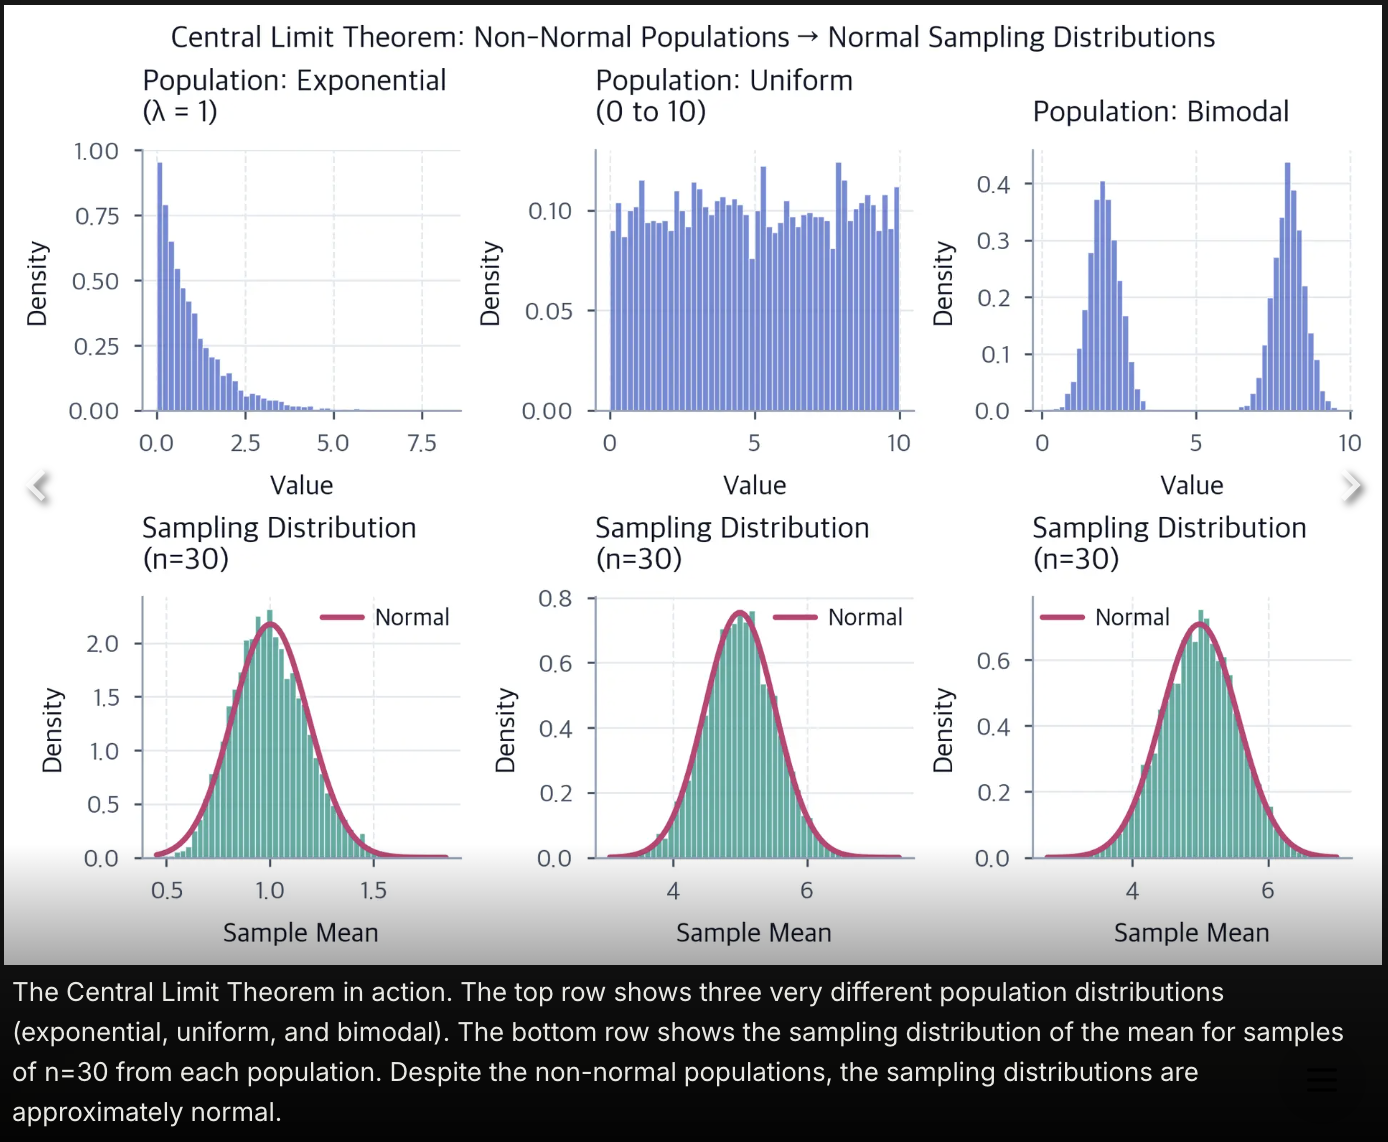

**When normality matters most**: For small samples (n < 20 or so), the shape of the population distribution affects test validity. Severe skewness or outliers can inflate or deflate Type I error rates.

**Checking normality**:** Use histograms and Q-Q plots to visually assess normality. Q-Q plots compare your data quantiles to theoretical normal quantiles. Points should fall roughly on a straight line if the data are normal.

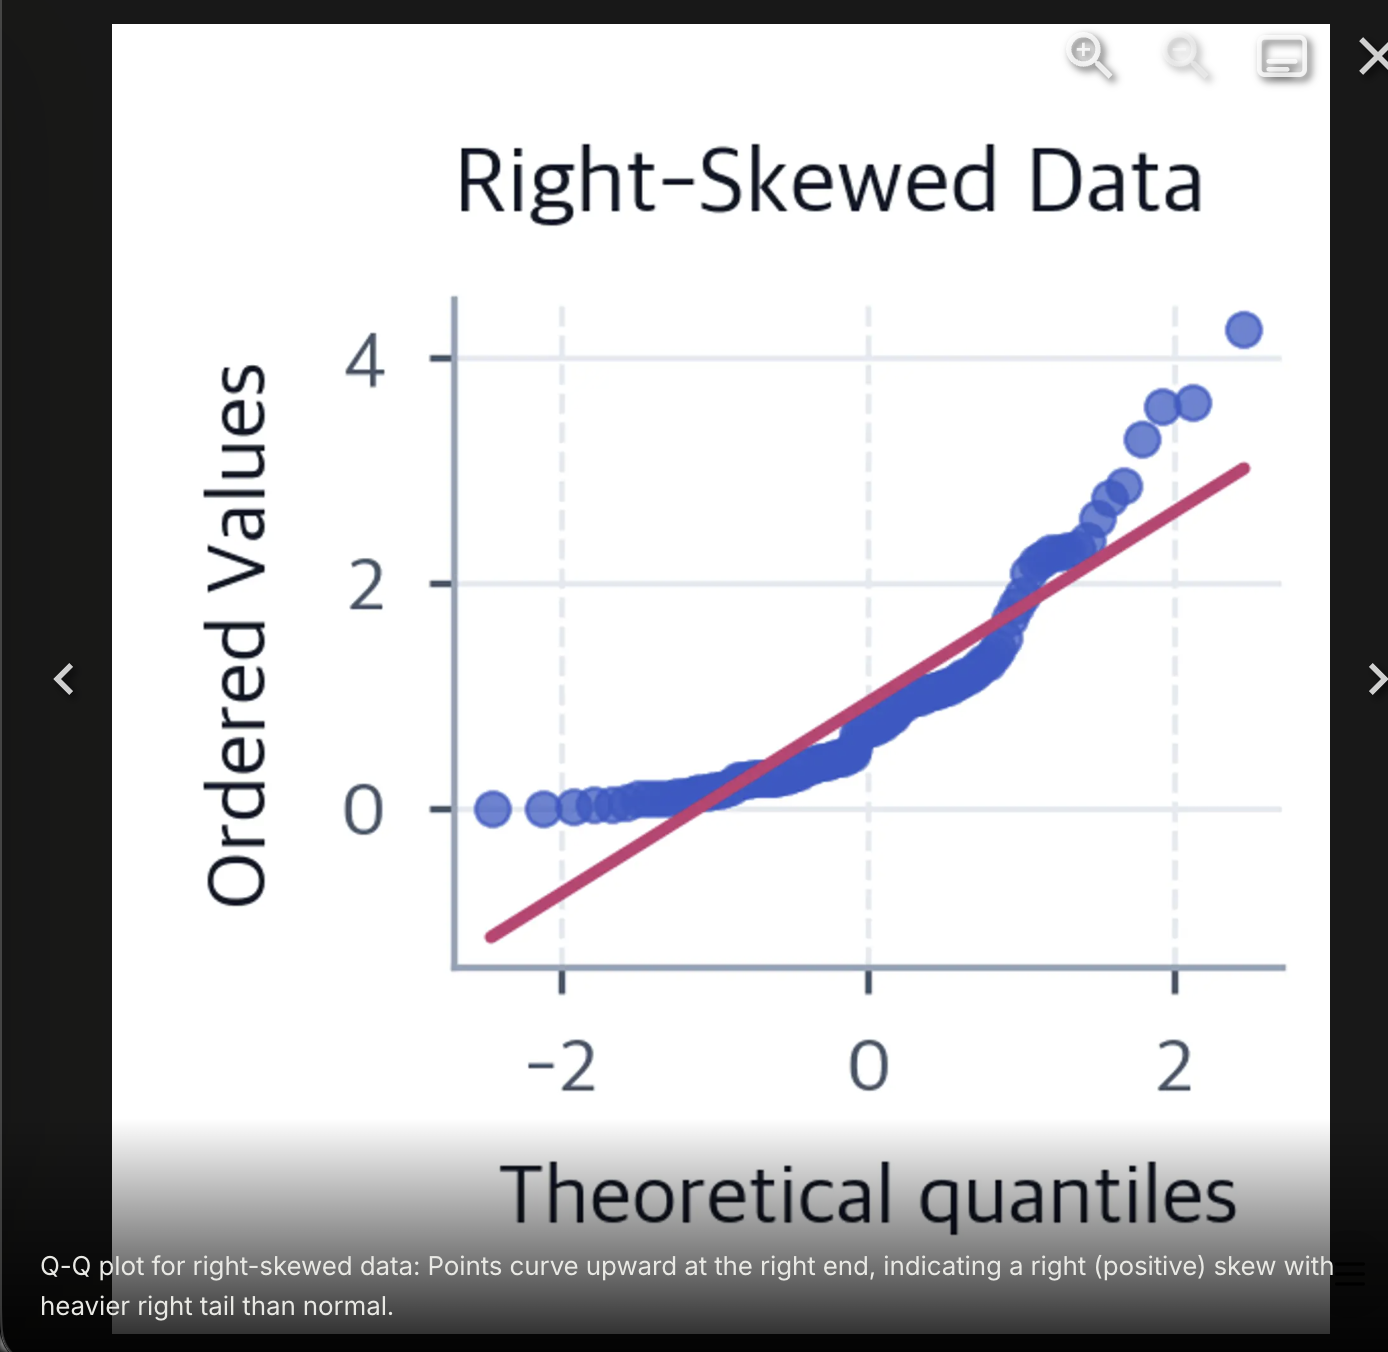
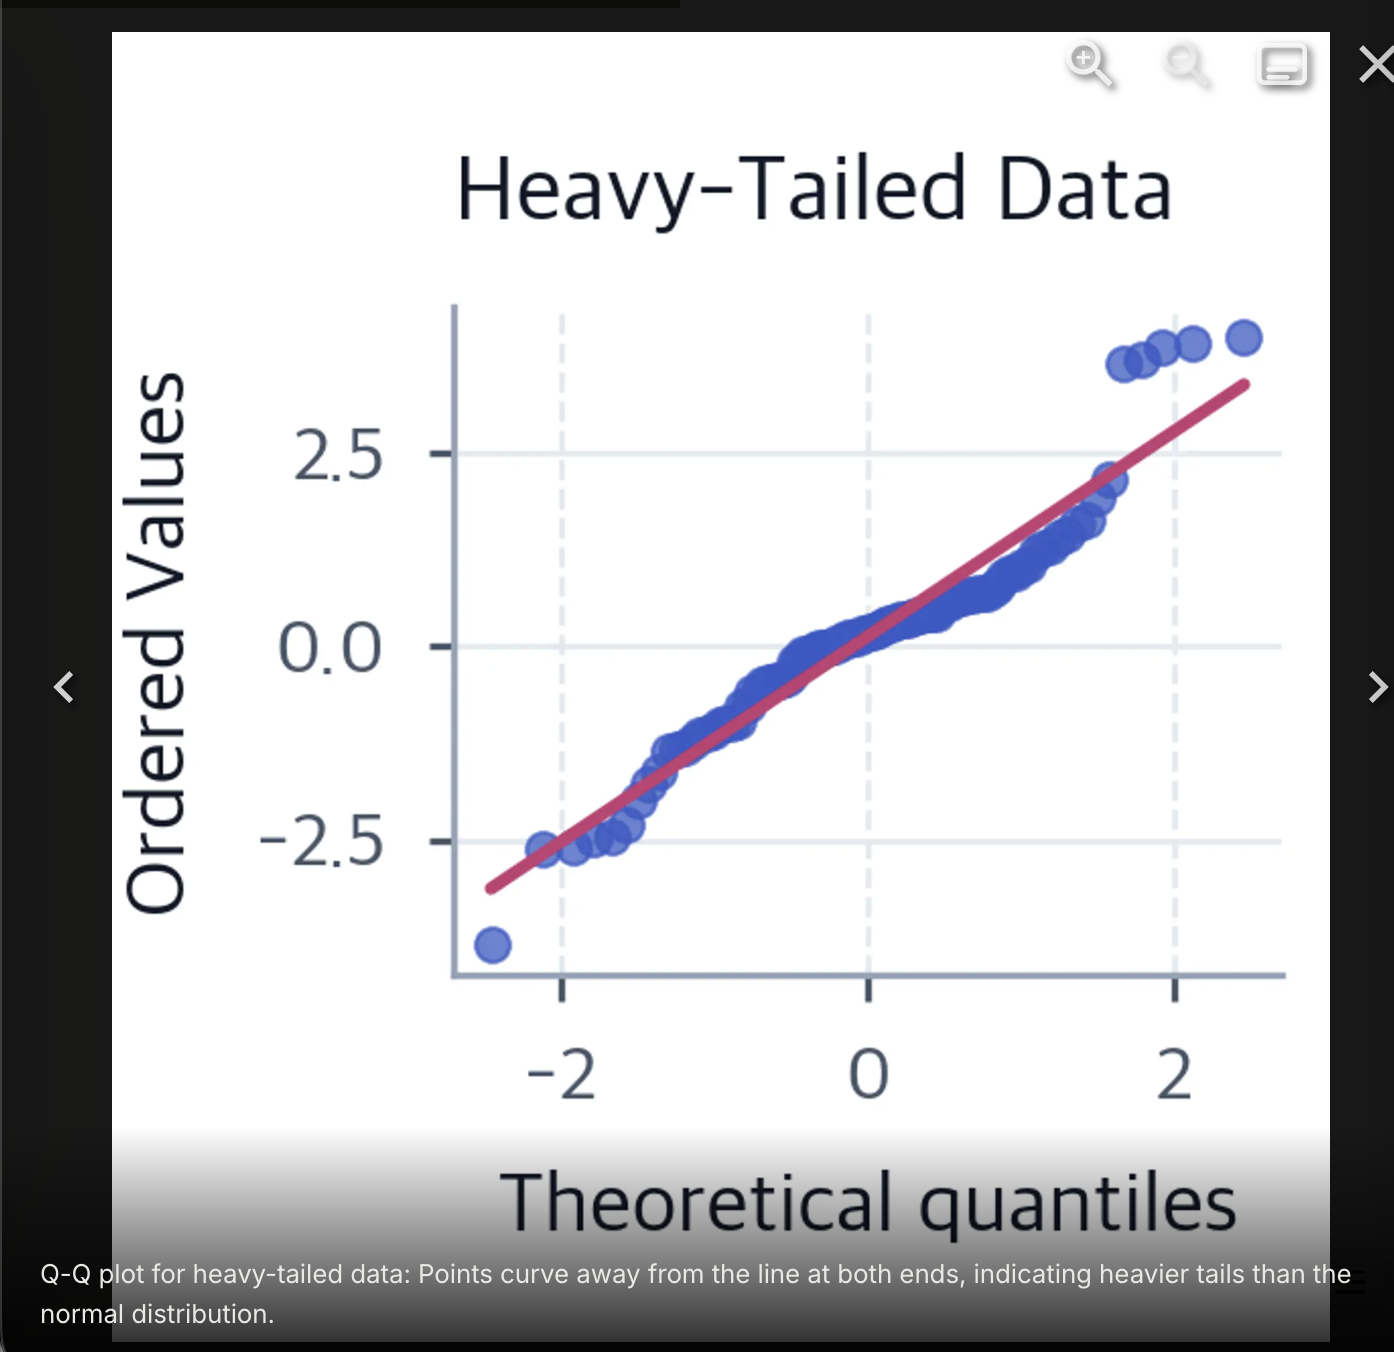
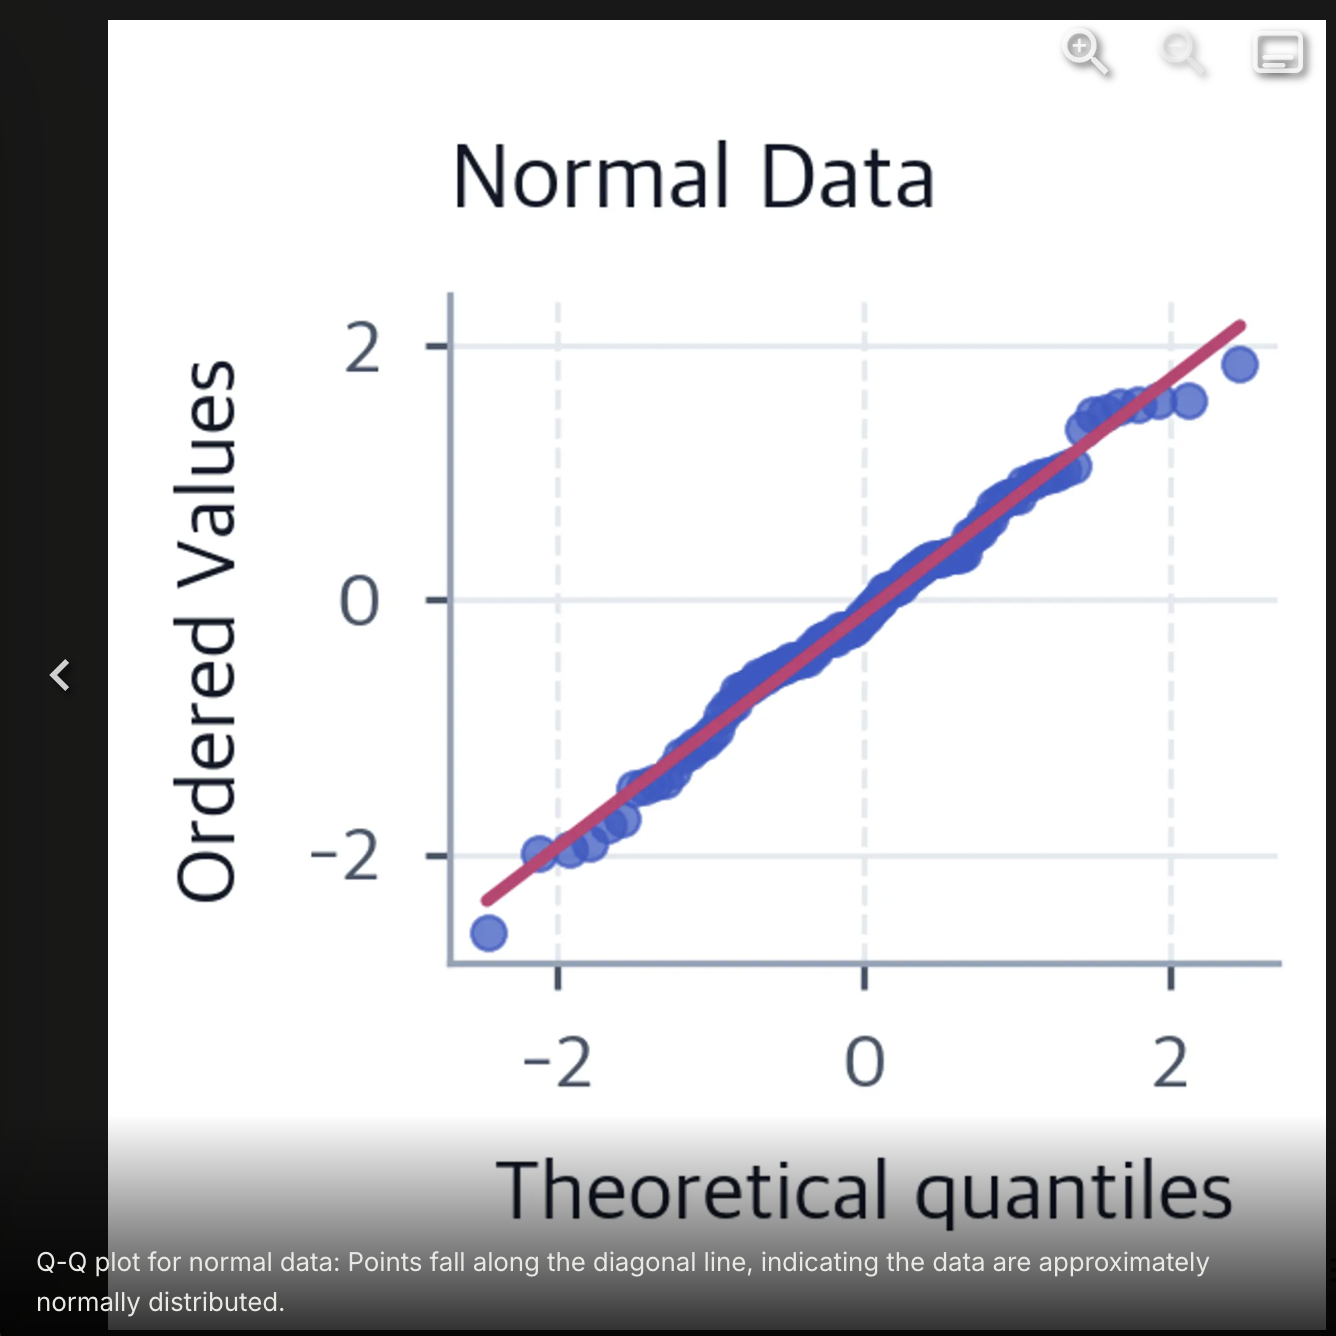


**Assumption 3: Equal Variances (Homoscedasticity)**

Two-sample t-tests can assume equal variances in both groups (pooled t-test) or allow unequal variances (Welch's t-test).

**Why equal variances matter for the pooled test**: The pooled t-test combines variance estimates from both groups to get a single "pooled" variance:
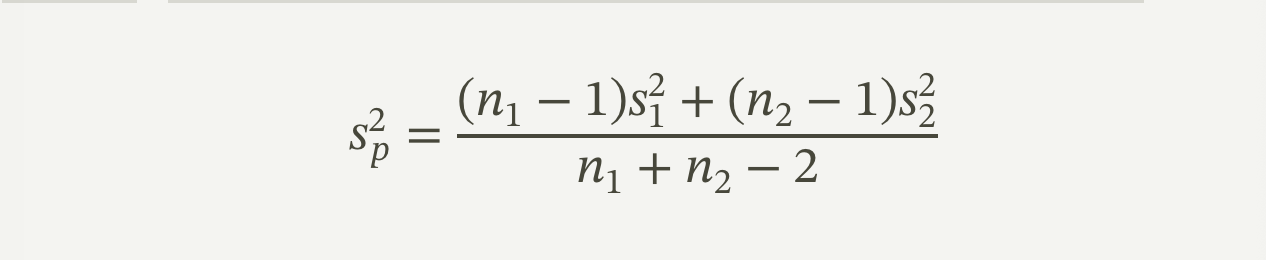

This pooling is only valid if both groups truly have the same variance. When variances differ, the pooled estimate doesn't accurately represent either group.

**What happens when variances differ**: The consequences depend on the relationship between variance and sample size:

- If the group with larger variance has smaller n: Type I error is inflated (you reject too often)
- If the group with larger variance has larger n: Type I error is deflated (you reject too rarely)
- If sample sizes are equal: Effects are minimal

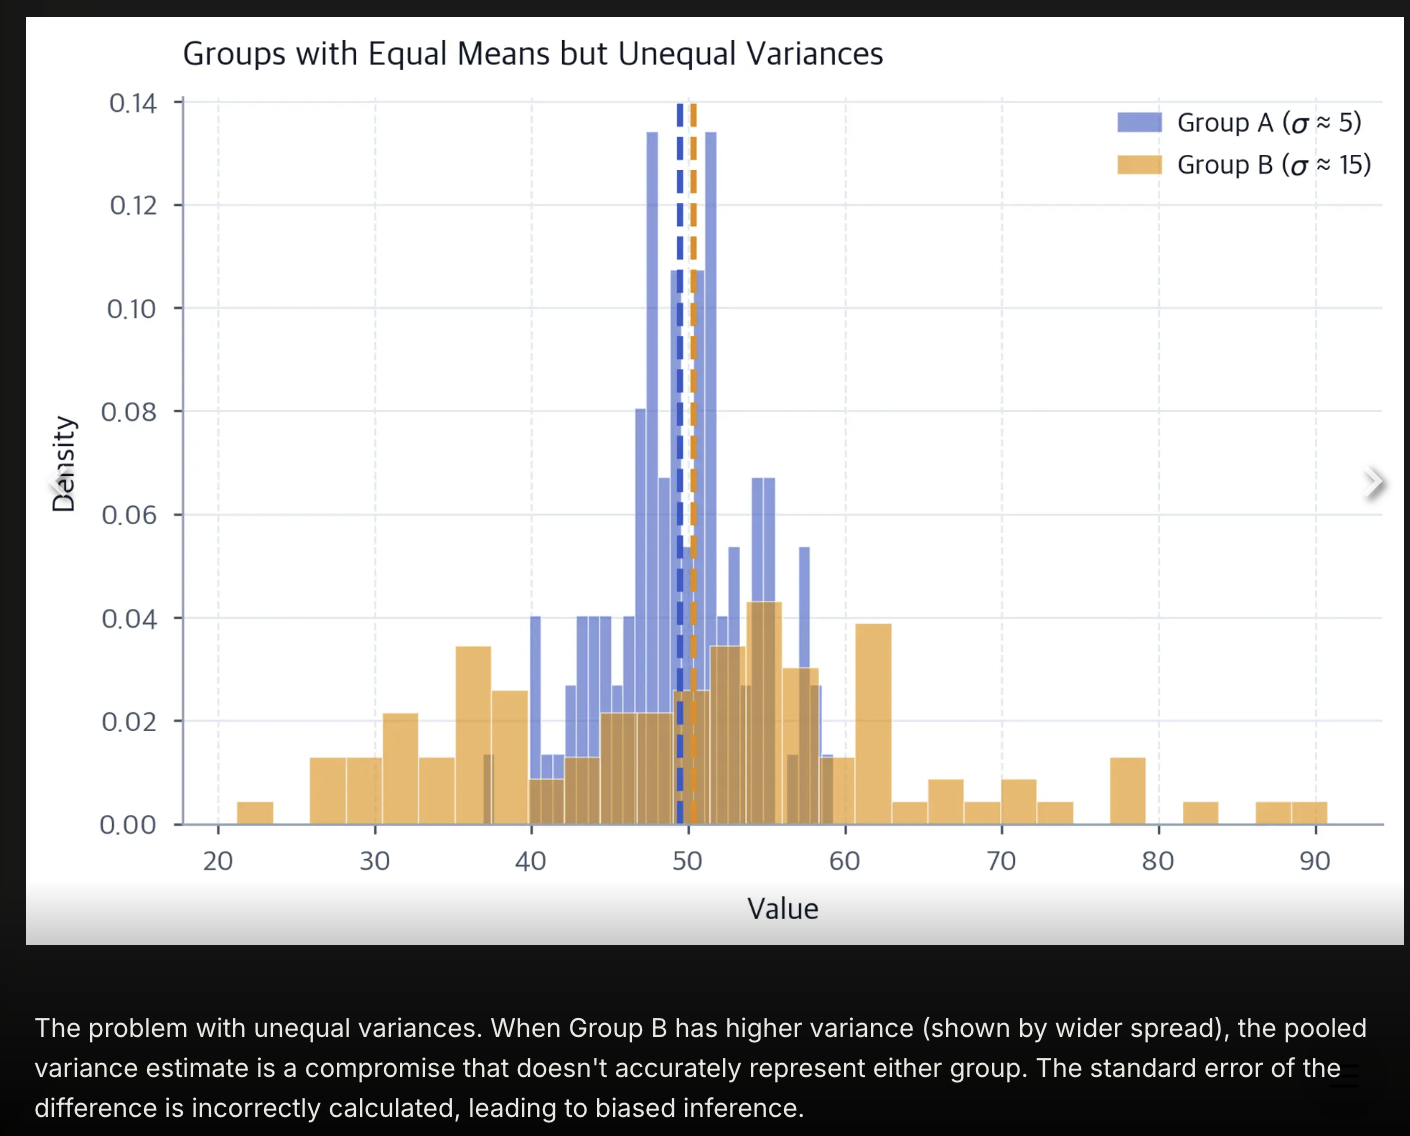

**The solution: Welch's t-test**: Welch's t-test doesn't assume equal variances. It calculates standard errors separately for each group and uses a modified degrees of freedom (the Welch-Satterthwaite approximation).

The key insight is that Welch's test is nearly as powerful as the pooled test when variances ARE equal, but much more accurate when they're not. This asymmetry makes Welch's test the recommended default.

## 5. Choosing Between Z-Tests and T-TestsLink Copied
The choice between z-tests and t-tests depends on whether you know the population standard deviation.

### The Z-Test: Known Variance
The z-test assumes you know the population standard deviation 
σ
:
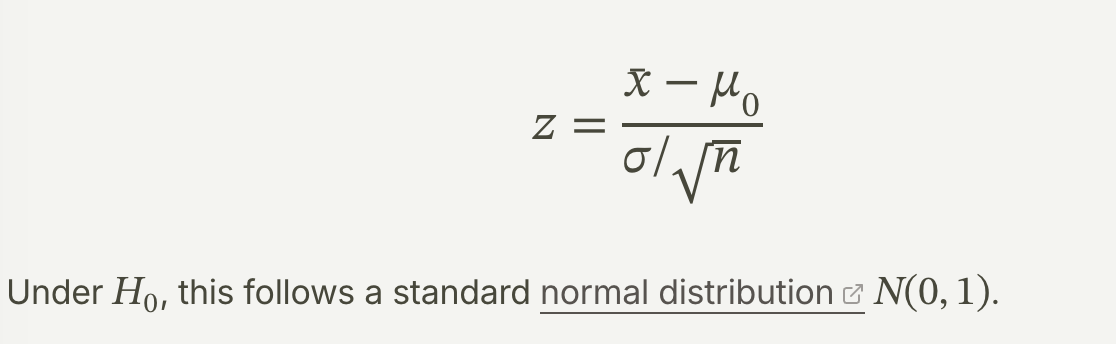

When do you know `σ` ? Rarely. Possible scenarios include:

- Measurement instruments with known precision from extensive calibration
- Standardized tests with established population parameters
- Very large historical datasets that effectively reveal the population


### The T-Test: Unknown Variance

The t-test estimates `σ` from the sample using `s`
:

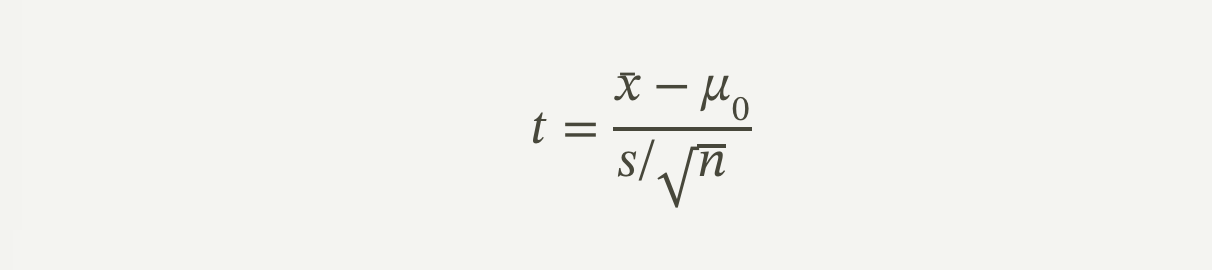

Why the t-distribution? When you estimate `σ` with  `s`
,you introduce additional uncertainty. The sample standard deviation 
`s` is itself a random variable. The t-distribution has heavier tails than the normal to account for this uncertainty.

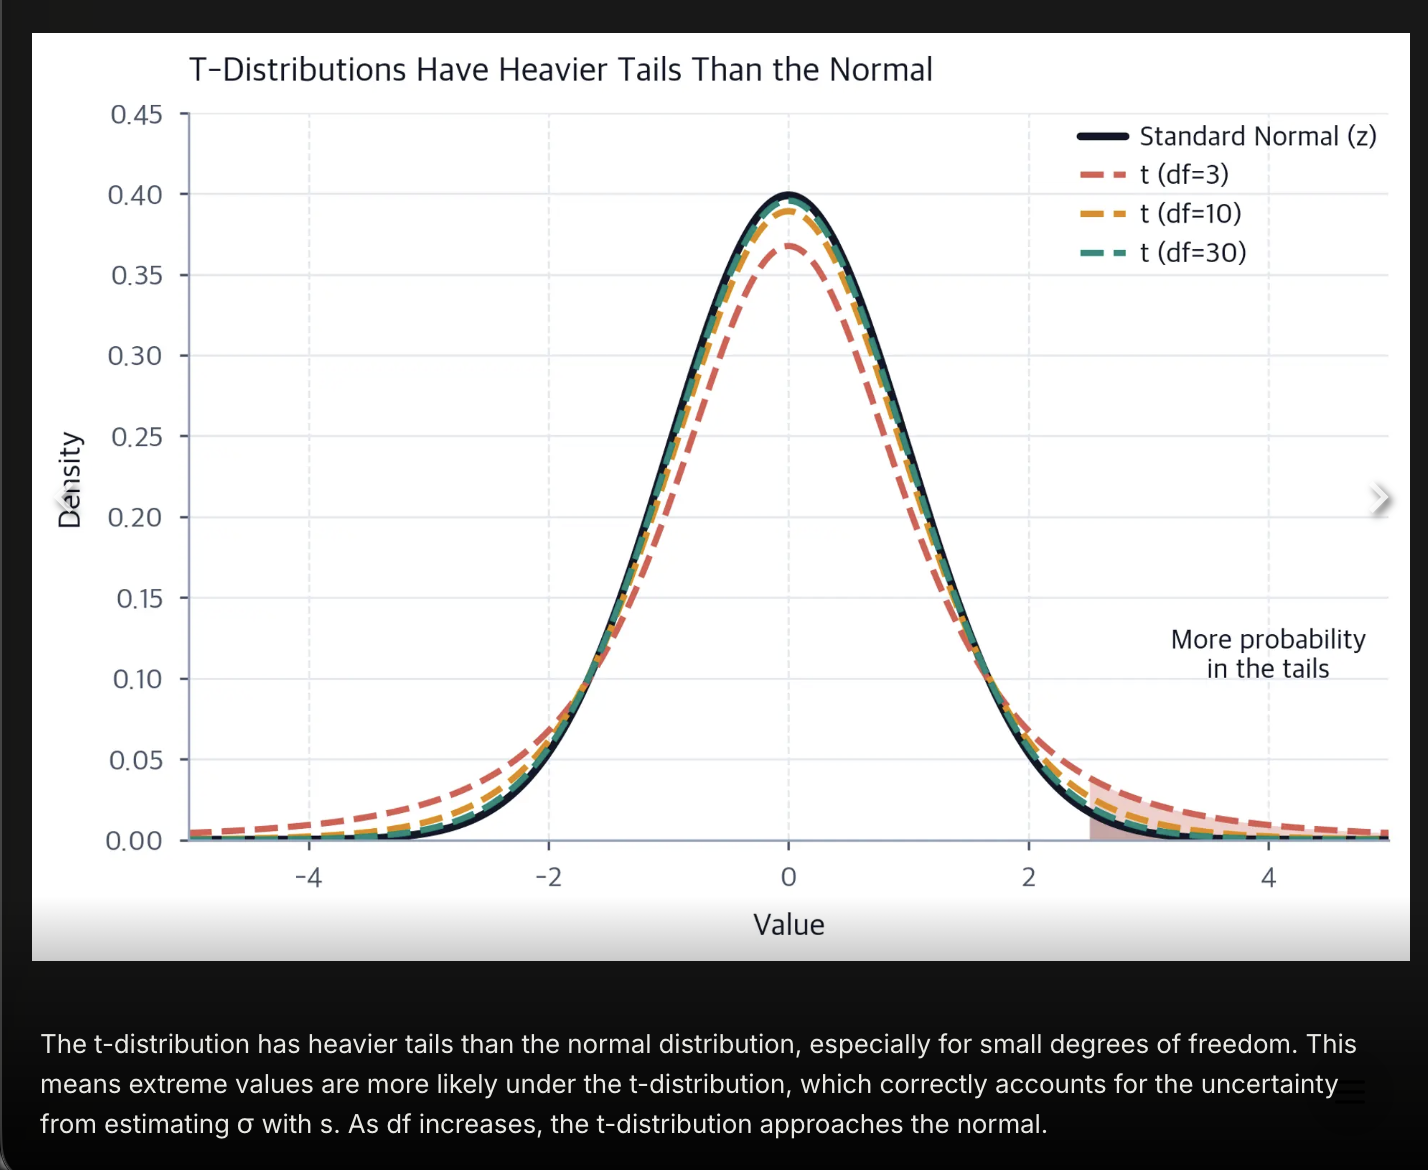



## 6. Welch's T-Test: The Safer Default

When comparing two independent groups, Welch's t-test should be your default choice.

### The Pooled vs Welch Comparison

**Pooled (Student's) t-test** assumes equal variances:
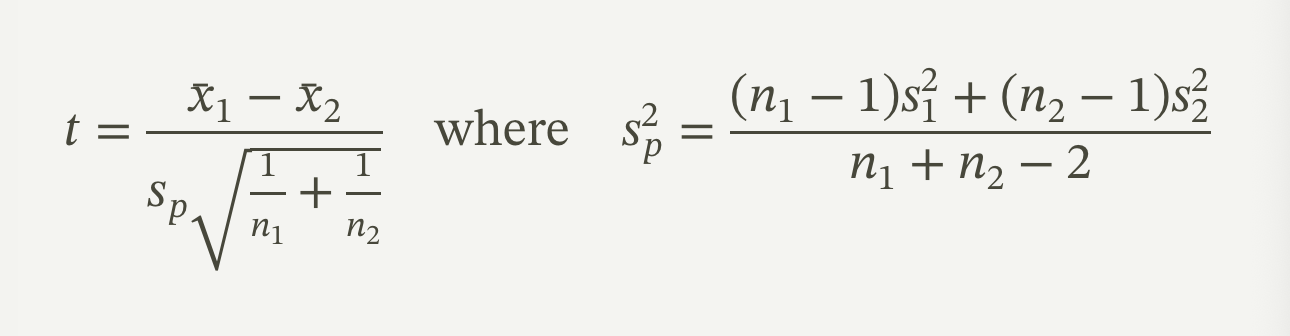

**Welch's t-test** allows unequal variances:
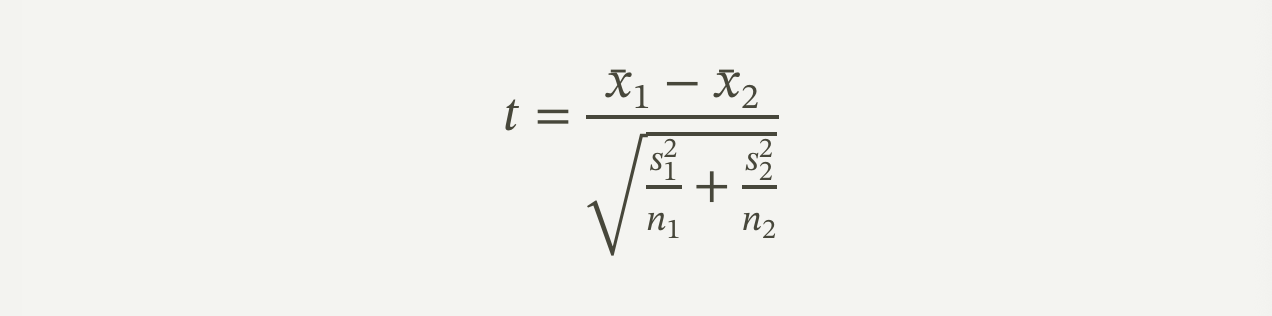
The degrees of freedom for Welch's test are calculated using the Welch-Satterthwaite formula:

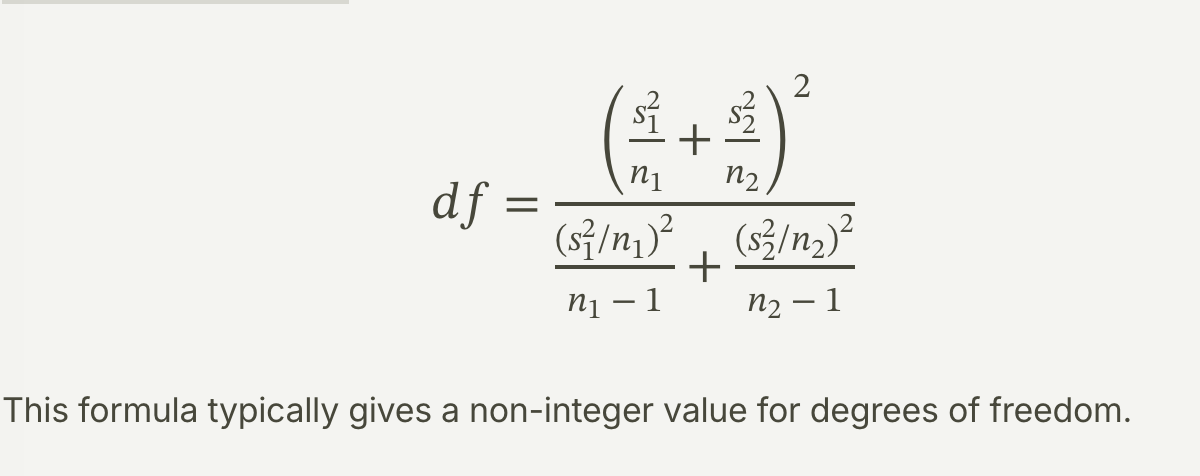

**When to use Which**:

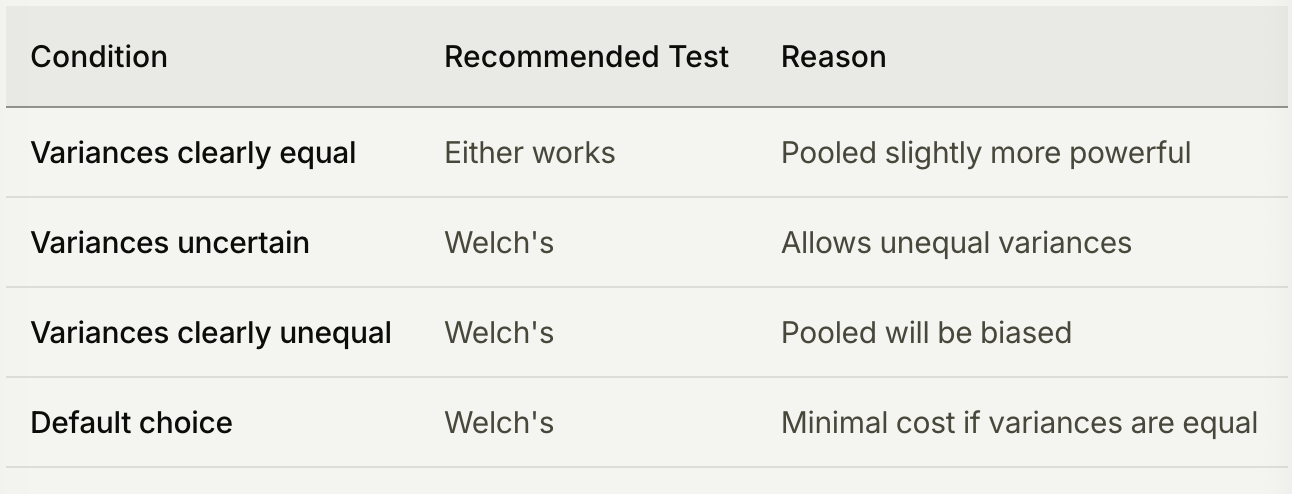

In [1]:
import numpy as np
from scipy import stats

# Example: Comparing two treatments with different variability
np.random.seed(42)

# Treatment A: Lower mean, lower variance
treatment_a = np.random.normal(50, 5, 25)

# Treatment B: Higher mean, higher variance
treatment_b = np.random.normal(55, 12, 30)

print(
    f"Treatment A: mean = {np.mean(treatment_a):.2f}, std = {np.std(treatment_a, ddof=1):.2f}, n = {len(treatment_a)}"
)
print(
    f"Treatment B: mean = {np.mean(treatment_b):.2f}, std = {np.std(treatment_b, ddof=1):.2f}, n = {len(treatment_b)}"
)
print()

# Pooled t-test (assumes equal variances)
t_pooled, p_pooled = stats.ttest_ind(treatment_a, treatment_b, equal_var=True)
print(f"Pooled t-test:  t = {t_pooled:.3f}, p = {p_pooled:.4f}")

# Welch's t-test (allows unequal variances)
t_welch, p_welch = stats.ttest_ind(treatment_a, treatment_b, equal_var=False)
print(f"Welch's t-test: t = {t_welch:.3f}, p = {p_welch:.4f}")

Treatment A: mean = 49.18, std = 4.78, n = 25
Treatment B: mean = 52.49, std = 10.79, n = 30

Pooled t-test:  t = -1.418, p = 0.1621
Welch's t-test: t = -1.509, p = 0.1389


## Summary

1. Confidence Intervals and Their Equivalence to Hypothesis Tests

- A 95% CI contains all parameter values that would not be rejected at the 0.05 level
- CIs are more informative than p-values because they show the range of plausible values
- CI width communicates precision: narrow intervals indicate precise estimates
Test Assumptions

2. Independence: The most important assumption. Violations lead to inflated Type I errors.
- Normality: The CLT makes this less critical for large samples (n > 30), but small samples require caution
- Equal variances: Use Welch's t-test as your default for two-sample comparisons

3. Choosing Between Tests

- Use t-tests when σ is unknown (almost always)
- Use Welch's t-test as the default for two-sample comparisons
The z-test is appropriate only when you know σ from prior information
